# 04 · Segmentation, Profiling and Handoff

**Purpose.** Answer the second analytical question — *how would different customer segments be affected by a price change?* — and put the result somewhere the business can use without asking for another analysis.

**Context, for anyone starting here.** This case study evaluates a proposed international day-pass price increase across the ~50,000-account synthetic book built in the data notebook. Notebook 03 puts a distribution on what that increase is worth over 12 months; this notebook asks who actually bears it.

**Why segment on response rather than on customers.** The obvious approach is to cluster accounts on their characteristics and then look at how each cluster responds. That produces groups that are easy to describe and analytically useless, because the thing being decided is price and the grouping was never about price.

Here the direction runs the other way. Accounts are grouped on their **modelled response to a price change**, and the characteristics are read back afterwards to describe what each group turned out to be. Profiling explains a segment; it does not create one.

**Group on the shape of the response, not its size.** Two accounts can lose the same revenue by very different routes: one abandons the pass entirely, the other keeps it and quietly halves its days. Identical expected revenue, completely different interventions — one needs a retention offer, the other needs a cheaper short-duration option. A single sensitivity score collapses that distinction; the full probability vector preserves it.

**Three deliverables**

| Section | Output |
|---|---|
| §2–4 | Segments, named and profiled |
| §5 | Where the revenue at stake actually sits, by segment |
| §6 | A star schema for Power BI so leaders run their own scenarios |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found — run data/00_generate_and_validate_data.ipynb and notebooks 01–03 first.")


accounts = load("accounts")
trips = load("trips").merge(accounts, on="account_id", how="left")
scored = load("scored_trips")
resp = load("account_price_response")
rev_tbl = load("revenue_by_state")
sim_sweep = load("simulation_price_sweep")
ground_truth = load("ground_truth")           # §4.1 validation only

CLASSES = ["no_purchase", "reduces", "unchanged", "increases"]

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})
INK, ACCENT, MUTED = "#201e1d", "#1c4ed8", "#9a9694"
PALETTE = ["#1c4ed8", "#17369b", "#6f8fe8", "#b23c17", "#9a9694", "#201e1d"]

print(f"{len(resp):,} accounts with a modelled price response")

29,312 accounts with a modelled price response


---
## 1 · The clustering input

Six features per account, all derived from the model rather than from raw behaviour:

| Feature | What it captures |
|---|---|
| `p_no_purchase` at standard price | baseline walk-away risk |
| `response_span` | how far that risk moves across the range |
| `p_reduces` at +20% | tendency to trim rather than quit |
| `p_increases` at −10% | responsiveness to a discount |
| `reduce_vs_quit` | **the shape** — which route the loss takes |
| `log(revenue)` | value at stake, so segments are decision-relevant |

`reduce_vs_quit` is the feature doing the real work. Without it, an account that abandons the pass and one that halves its days land in the same cluster whenever their expected loss matches, and the segmentation stops being actionable.

Revenue is included deliberately. A segment that behaves distinctively but carries no revenue is a curiosity; one that behaves distinctively and carries a quarter of the book is a decision.

In [2]:
# Per-account state mix at the standard price, and value
sc = scored.merge(trips[["trip_id", "pass_revenue"]], on="trip_id", how="left")
acct_state = sc.groupby("account_id").agg(
    trips=("trip_id", "size"),
    revenue=("pass_revenue", "sum"),
    p_reduces=("p_reduces", "mean"),
    p_increases=("p_increases", "mean"),
).reset_index()

seg = resp.merge(acct_state, on="account_id", how="inner")
seg["baseline_risk"] = seg["p_np_1.00"]
seg["response_span"] = seg["p_np_1.20"] - seg["p_np_0.90"]
# The shape score: blends the account's CURRENT trim tendency (p_reduces, at
# standard price) with its FUTURE walk-away risk at the top of the tested
# range (p_np_1.20). An account that already reduces often but rarely quits
# scores high; one whose no-purchase risk dominates scores low — which is
# exactly the "trims vs quits" distinction §1's markdown motivates.
seg["reduce_vs_quit"] = seg["p_reduces"] / (seg["p_reduces"] + seg["p_np_1.20"] + 1e-9)
seg["log_revenue"] = np.log1p(seg["revenue"])

FEATS = ["baseline_risk", "response_span", "p_reduces", "p_increases",
         "reduce_vs_quit", "log_revenue"]
seg = seg.dropna(subset=FEATS)
print(seg[FEATS].describe().round(4).to_string())

corr = seg[FEATS].corr()
print("\nFeature correlations — anything above 0.95 is treated as redundant here.")
print("Note this is a high bar: baseline_risk/response_span (0.72) and")
print("reduce_vs_quit/baseline_risk (-0.68) are moderate-to-high and will still")
print("pull k-means' Euclidean distance in their direction even after scaling —")
print("acceptable because reduce_vs_quit is deliberately doing the shape work the")
print("other features can't, not because the correlation is negligible.")
print(corr.round(2).to_string())
high = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATS)
        for b in FEATS[i + 1:] if abs(corr.loc[a, b]) > 0.95]
print(f"\nRedundant pairs: {high if high else 'none'}")

       baseline_risk  response_span   p_reduces  p_increases  reduce_vs_quit  log_revenue
count     29312.0000     29312.0000  29312.0000   29312.0000      29312.0000   29312.0000
mean          0.0992         0.0426      0.1163       0.0685          0.4813       4.5823
std           0.0251         0.0410      0.0396       0.0066          0.1051       1.4087
min           0.0558        -0.0405      0.0000       0.0295          0.0000       0.0000
25%           0.0769         0.0253      0.0955       0.0661          0.4166       4.0604
50%           0.1015         0.0342      0.1062       0.0680          0.4736       4.7958
75%           0.1143         0.0445      0.1270       0.0717          0.5504       5.4403
max           0.3863         0.5598      0.8440       0.1541          0.9328       8.6721

Feature correlations — anything above 0.95 is treated as redundant here.
Note this is a high bar: baseline_risk/response_span (0.72) and
reduce_vs_quit/baseline_risk (-0.68) are moderate-to

---
## 2 · How many segments?

Two criteria, and the second usually beats the first.

**Statistical:** silhouette score, which measures whether the clusters are actually separated.

**Practical:** whether the business can act on the result. Nine segments that each need their own price are not a pricing strategy; they are a spreadsheet nobody will maintain. Four or five is the range where distinct treatment stays realistic.

If the two disagree, the practical criterion wins — an unimplementable segmentation delivers nothing regardless of its silhouette.

       inertia  silhouette  smallest segment
k                                           
2  138477.6991      0.2258            0.4255
3  113089.3846      0.2525            0.0580
4   96406.2962      0.2503            0.0572
5   84878.6924      0.2790            0.0488
6   75930.7812      0.2810            0.0451
7   67690.9996      0.2834            0.0036
8   63099.2963      0.2825            0.0036

Silhouette argmax at k=7 (0.283); chosen k=5 (0.279).
Chosen: k = 5
Enough separation to distinguish the response shapes, few enough that each
segment can carry a distinct pricing treatment someone will actually run.


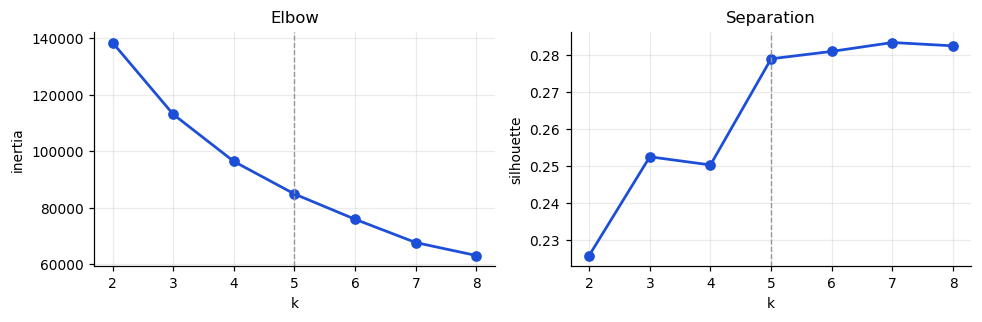

In [3]:
Z = StandardScaler().fit_transform(seg[FEATS])
sample = np.random.default_rng(0).choice(len(Z), size=min(8000, len(Z)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Z[sample], km.labels_[sample]),
        "smallest segment": sizes.min(),
    })
k_tbl = pd.DataFrame(rows).set_index("k").round(4)
print(k_tbl.to_string())

K = 5
best_k = int(k_tbl["silhouette"].idxmax())
print(f"\nSilhouette argmax at k={best_k} ({k_tbl.loc[best_k, 'silhouette']:.3f}); "
      f"chosen k={K} ({k_tbl.loc[K, 'silhouette']:.3f}).")
print(f"Chosen: k = {K}")
print("Enough separation to distinguish the response shapes, few enough that each")
print("segment can carry a distinct pricing treatment someone will actually run.")

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Z)
seg["cluster"] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_tbl.index, k_tbl["inertia"], marker="o", color=ACCENT, linewidth=1.8)
axes[0].axvline(K, color=MUTED, linestyle="--", linewidth=0.9)
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow")
axes[1].plot(k_tbl.index, k_tbl["silhouette"], marker="o", color=ACCENT, linewidth=1.8)
axes[1].axvline(K, color=MUTED, linestyle="--", linewidth=0.9)
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
axes[1].set_title("Separation")
plt.tight_layout()
plt.show()

---
## 3 · Profiling: what did the clusters turn out to be?

The clusters exist in response space and have no names. Reading their characteristics back is what turns *cluster 3* into a group a product owner recognises and can make a decision about.

Every column below is descriptive. None of it went into the clustering.

In [4]:
prof = seg.merge(accounts[["account_id", "is_business", "lines_on_account",
                          "tenure_months", "plan_tier"]], on="account_id", how="left")
trip_ch = trips.groupby("account_id").agg(
    avg_days=("days_traveled", "mean"),
    avg_party=("lines_traveling", "mean"),
    top_region=("region", lambda s: s.mode().iat[0] if len(s) else "n/a"),
    avg_ease=("substitute_ease", "mean"),
).reset_index()
prof = prof.merge(trip_ch, on="account_id", how="left")

summary = prof.groupby("cluster").agg(
    accounts=("account_id", "size"),
    revenue=("revenue", "sum"),
    rev_per_acct=("revenue", "mean"),
    trips_per_acct=("trips", "mean"),
    business=("is_business", "mean"),
    avg_days=("avg_days", "mean"),
    avg_party=("avg_party", "mean"),
    tenure=("tenure_months", "mean"),
    ease=("avg_ease", "mean"),
    baseline_risk=("baseline_risk", "mean"),
    response_span=("response_span", "mean"),
    reduce_vs_quit=("reduce_vs_quit", "mean"),
)
summary["rev_share"] = summary["revenue"] / summary["revenue"].sum()
summary["acct_share"] = summary["accounts"] / summary["accounts"].sum()

print("Segment profiles — response features first, characteristics after\n")
print(summary[["accounts", "acct_share", "rev_share", "rev_per_acct",
               "baseline_risk", "response_span", "reduce_vs_quit"]].round(4).to_string())
print()
print(summary[["business", "trips_per_acct", "avg_days", "avg_party",
               "tenure", "ease"]].round(2).to_string())

print("\nDominant destination by segment")
print(prof.groupby("cluster")["top_region"]
      .agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict()).to_string())

Segment profiles — response features first, characteristics after

         accounts  acct_share  rev_share  rev_per_acct  baseline_risk  response_span  reduce_vs_quit
cluster                                                                                             
0            1430      0.0488     0.0003        1.2664         0.1099         0.0437          0.4260
1            8526      0.2909     0.4236      268.6642         0.0720         0.0239          0.5584
2            2776      0.0947     0.0348       67.8903         0.1019         0.0184          0.6395
3            1573      0.0537     0.0349      120.1238         0.1524         0.1816          0.2700
4           15007      0.5120     0.5063      182.4495         0.1075         0.0431          0.4356

         business  trips_per_acct  avg_days  avg_party  tenure  ease
cluster                                                             
0            0.07            1.07      6.80       1.48   69.41  0.67
1            0.94 

In [5]:
# Name each segment from what the numbers actually say, rather than by hand
sp = summary.copy()
sp["rank_span"] = sp["response_span"].rank(pct=True)
sp["rank_shape"] = sp["reduce_vs_quit"].rank(pct=True)
sp["rank_value"] = sp["rev_per_acct"].rank(pct=True)


# A cluster carrying essentially no revenue is not a pricing segment. These are
# accounts that travelled but never bought the pass, and leaving them in would
# dilute every average and put a segment on the decision map that no price
# change can move.
DORMANT_REV_SHARE = 0.005
sp["dormant"] = summary["rev_share"] < DORMANT_REV_SHARE


def name_segment(r):
    # Rank thresholds below are chosen to produce a small set of recognisable,
    # non-overlapping business labels at K=5 — not derived from a statistical
    # test. They should be re-eyeballed (via the printed segment summaries
    # below) if K or the account population changes materially.
    if r["dormant"]:
        return "Dormant — travels, does not buy"
    if r["rank_span"] <= 0.3 and r["rank_value"] >= 0.6:
        return "Anchor — high value, low sensitivity"
    if r["rank_span"] <= 0.35:
        return "Steady — barely notices the price"
    if r["rank_span"] >= 0.7 and r["rank_shape"] >= 0.6:
        return "Trimmers — stay but buy less"
    if r["rank_span"] >= 0.7:
        return "Flight risk — walks away"
    return "Swing — moves at the margin"


summary["segment"] = sp.apply(name_segment, axis=1)
summary["is_dormant"] = sp["dormant"]

# Two clusters can land in the same bucket. Rather than tacking an index onto a
# duplicate name, separate them on the next most decision-relevant axis: value.
for nm, grp in list(summary.groupby("segment")):
    if len(grp) == 1:
        continue
    ranked = grp["rev_per_acct"].rank(ascending=False)
    qual = {1: "higher value", 2: "mid value", 3: "lower value"}
    for i in grp.index:
        head, _, tail = nm.partition(" — ")
        summary.loc[i, "segment"] = f"{head} ({qual.get(int(ranked[i]), 'other')}) — {tail}"

NAMES = summary["segment"].to_dict()
prof["segment"] = prof["cluster"].map(NAMES)
seg["segment"] = seg["cluster"].map(NAMES)

n_dorm = int(summary["is_dormant"].sum())
if n_dorm:
    d = summary[summary["is_dormant"]]
    print(f"Set aside as dormant: {int(d['accounts'].sum()):,} accounts "
          f"({d['acct_share'].sum():.1%}) carrying {d['rev_share'].sum():.2%} of revenue.")
    print("They travel but never buy the pass, so no price answers them. They are a")
    print("conversion question, not a pricing one, and are excluded from §4-§5.\n")

print("Segments\n")
for c in summary.index:
    r = summary.loc[c]
    print(f"{r['segment']}")
    print(f"   {r['accounts']:,} accounts ({r['acct_share']:.1%}) · "
          f"{r['rev_share']:.1%} of revenue · ${r['rev_per_acct']:,.0f} each")
    print(f"   walk-away risk {r['baseline_risk']:.3f} → moves {r['response_span']:+.3f} "
          f"across the range · {r['business']:.0%} business · "
          f"{r['trips_per_acct']:.1f} trips\n")

Set aside as dormant: 1,430 accounts (4.9%) carrying 0.03% of revenue.
They travel but never buy the pass, so no price answers them. They are a
conversion question, not a pricing one, and are excluded from §4-§5.

Segments

Dormant — travels, does not buy
   1,430 accounts (4.9%) · 0.0% of revenue · $1 each
   walk-away risk 0.110 → moves +0.044 across the range · 7% business · 1.1 trips

Swing (higher value) — moves at the margin
   8,526 accounts (29.1%) · 42.4% of revenue · $269 each
   walk-away risk 0.072 → moves +0.024 across the range · 94% business · 6.1 trips

Steady — barely notices the price
   2,776 accounts (9.5%) · 3.5% of revenue · $68 each
   walk-away risk 0.102 → moves +0.018 across the range · 29% business · 1.5 trips

Flight risk — walks away
   1,573 accounts (5.4%) · 3.5% of revenue · $120 each
   walk-away risk 0.152 → moves +0.182 across the range · 1% business · 1.6 trips

Swing (mid value) — moves at the margin
   15,007 accounts (51.2%) · 50.6% of revenue · $

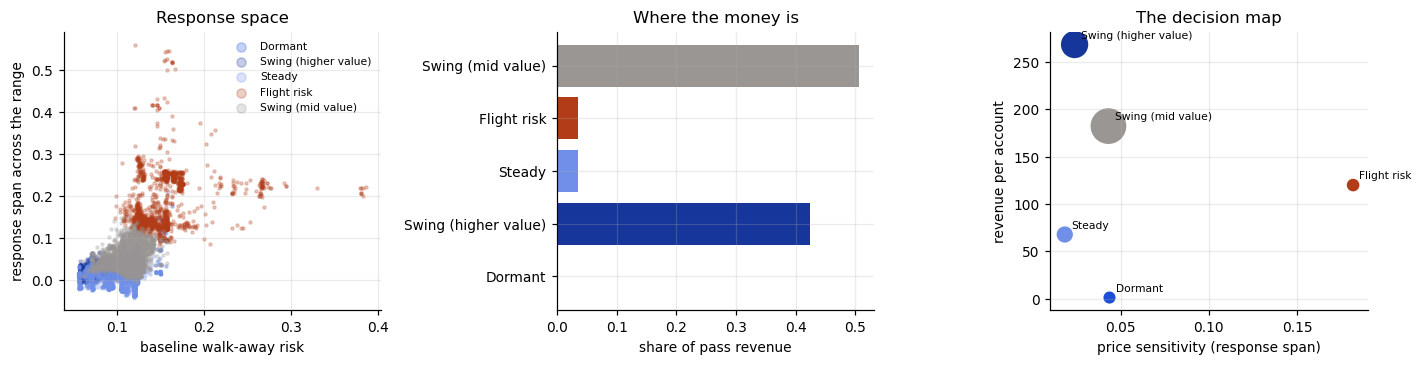

The third panel is the one to put in front of leadership: upper-left is
where a price increase earns most and risks least.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for i, c in enumerate(summary.index):
    m = seg["cluster"] == c
    axes[0].scatter(seg.loc[m, "baseline_risk"], seg.loc[m, "response_span"],
                    s=4, alpha=0.25, color=PALETTE[i % len(PALETTE)],
                    label=summary.loc[c, "segment"].split(" — ")[0])
axes[0].set_xlabel("baseline walk-away risk")
axes[0].set_ylabel("response span across the range")
axes[0].set_title("Response space")
axes[0].legend(frameon=False, fontsize=7, markerscale=3)

axes[1].barh(summary["segment"].str.split(" — ").str[0], summary["rev_share"],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
axes[1].set_xlabel("share of pass revenue")
axes[1].set_title("Where the money is")

axes[2].scatter(summary["response_span"], summary["rev_per_acct"],
                s=summary["accounts"] / 30,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
for c in summary.index:
    axes[2].annotate(summary.loc[c, "segment"].split(" — ")[0],
                     (summary.loc[c, "response_span"], summary.loc[c, "rev_per_acct"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[2].set_xlabel("price sensitivity (response span)")
axes[2].set_ylabel("revenue per account")
axes[2].set_title("The decision map")
plt.tight_layout()
plt.show()

print("The third panel is the one to put in front of leadership: upper-left is")
print("where a price increase earns most and risks least.")

### 3.1 Are the segments real?

A clustering algorithm returns clusters whether or not the structure exists. Two checks before anyone acts on these.

**Stability.** Refit on random halves of the data. If accounts land together consistently, the structure is in the data; if the assignments shuffle, it is in the algorithm.

**Recovery.** Because the data is synthetic, the true sensitivity is known. Segments that separate on true sensitivity are finding the real mechanism, not a projection artefact — the check production data can never provide.

In [7]:
rng = np.random.default_rng(5)


# Nearest centroid by hand rather than .predict(), which routes through
# threadpoolctl and breaks on some older OpenBLAS builds. Defined once here
# rather than inside the loop below — it doesn't depend on the split, so
# redefining it every iteration was pure overhead.
def assign(centers):
    d = ((Z[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return d.argmin(axis=1)


agree = []
for _ in range(5):
    half = rng.random(len(Z)) < 0.5
    a = KMeans(n_clusters=K, n_init=10, random_state=1).fit(Z[half])
    b = KMeans(n_clusters=K, n_init=10, random_state=2).fit(Z[~half])

    la = assign(a.cluster_centers_)
    lb = assign(b.cluster_centers_)
    ct = pd.crosstab(la, lb)
    agree.append(ct.max(axis=1).sum() / ct.values.sum())
print(f"Split-half agreement: {np.mean(agree):.1%} (mean of 5 splits)")
print("Above ~80% means the structure is in the data, not the algorithm.\n")

gt = prof.merge(ground_truth[["account_id", "price_sensitivity", "sensitivity_decile"]],
                on="account_id", how="inner")
recov = gt.groupby("segment").agg(
    accounts=("account_id", "size"),
    true_sensitivity=("price_sensitivity", "mean"),
    modelled_span=("response_span", "mean"),
).round(4).sort_values("true_sensitivity")
print("True sensitivity by segment (less negative = less sensitive)\n")
print(recov.to_string())

spread = recov["true_sensitivity"].max() - recov["true_sensitivity"].min()
print(f"\nSpread in true sensitivity across segments: {spread:.3f}")
print("A wide spread means the segments capture the real mechanism. Near zero")
print("would mean they separate on something else entirely.")

check = recov["true_sensitivity"].corr(recov["modelled_span"], method="spearman")
print(f"Rank correlation, true sensitivity vs modelled span: {check:+.2f}")
print("(negative is correct: more negative true sensitivity = wider modelled span)")

Split-half agreement: 98.4% (mean of 5 splits)
Above ~80% means the structure is in the data, not the algorithm.

True sensitivity by segment (less negative = less sensitive)

                                            accounts  true_sensitivity  modelled_span
segment                                                                              
Flight risk — walks away                        1573           -1.4808         0.1816
Swing (mid value) — moves at the margin        15007           -1.4208         0.0431
Dormant — travels, does not buy                 1430           -1.4036         0.0437
Steady — barely notices the price               2776           -1.2127         0.0184
Swing (higher value) — moves at the margin      8526           -0.5553         0.0239

Spread in true sensitivity across segments: 0.925
A wide spread means the segments capture the real mechanism. Near zero
would mean they separate on something else entirely.
Rank correlation, true sensitivity vs modelled 

---
## 4 · What price does each segment want?

The reason for segmenting at all. A single company-wide price is one number chosen for a population that does not exist; a segment-level curve says where the increase earns and where it costs.

The revenue curve is rebuilt per segment from the state probabilities and the revenue table, using the same arithmetic as notebook 03 restricted to each group's trips — **including the cost of lost relationships**. Pass revenue alone rises monotonically across this range, so a curve that ignores departures points every segment at the cap and tells you nothing.

horizon: last 12 months, 51,838 trips — same as notebook 03
case: conservative, response x1.87, depth x1.06

Revenue vs no change, by segment

segment           Dormant — travels, does not buy  Flight risk — walks away  Steady — barely notices the price  Swing (higher value) — moves at the margin  Swing (mid value) — moves at the margin
price_multiplier                                                                                                                                                                                   
0.9                                       -0.0311                   -0.0144                            -0.0258                                     -0.0451                                  -0.0328
1.0                                        0.0000                    0.0000                             0.0000                                      0.0000                                   0.0000
1.1                                        0.0105                   -0.00

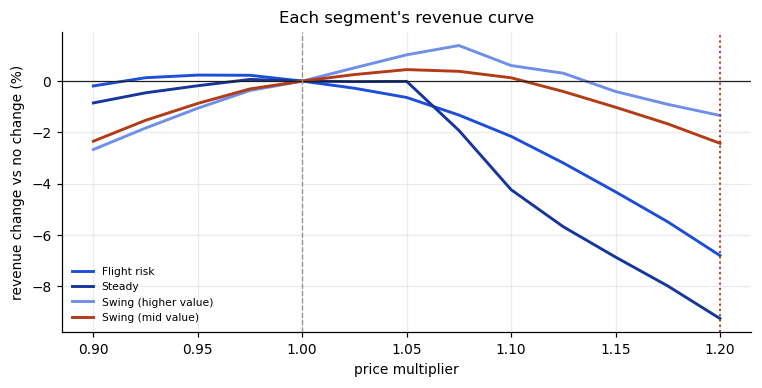

In [8]:
sweep = load("price_sweep").set_index("price_multiplier")
GRID = np.round(np.sort(rev_tbl["price_multiplier"].unique()), 4)

trip_seg = trips[["trip_id", "account_id"]].merge(
    seg[["account_id", "segment"]], on="account_id", how="inner")
p_std = scored.set_index("trip_id")[[f"p_{c}" for c in CLASSES]]
rev_w = rev_tbl.pivot_table(index="trip_id", columns="price_multiplier",
                            values=[f"rev_{c}" for c in CLASSES])


def _logp(p):
    """Log-probability, the correct scale for a multiclass shift.

    softmax(logit(p)) renormalises the ODDS rather than the probabilities and
    does not return p — it understates the small classes badly.
    """
    return np.log(np.clip(p, 1e-9, 1.0))


# --- match notebook 03 exactly ------------------------------------------------
# Two things must line up or the notebooks recommend different prices on numbers
# that differ by a multiple: the HORIZON (05 projects the most recent twelve
# months forward, not all twenty-four) and the CASE (05 reads its recommendation
# off the conservative run, with both measured biases applied).
asm0 = load("simulation_assumptions").set_index("assumption")["value"]
RESPONSE_SCALE = float(asm0.get("response scale (conservative)", 1.0))
DEPTH_SCALE = float(asm0.get("depth bias (conservative)", 1.0))

FWD = trips[trips["month"] >= trips["month"].max() - 11]["trip_id"].to_numpy()
print(f"horizon: last 12 months, {len(FWD):,} trips — same as notebook 03")
print(f"case: conservative, response x{RESPONSE_SCALE:.2f}, depth x{DEPTH_SCALE:.2f}\n")

ref = sweep.iloc[np.argmin(np.abs(sweep.index.to_numpy() - 1.0))][CLASSES].to_numpy()
ids = trip_seg["trip_id"].to_numpy()
ids = ids[np.isin(ids, p_std.index) & np.isin(ids, rev_w.index) & np.isin(ids, FWD)]
trip_seg = trip_seg[trip_seg.trip_id.isin(ids)]
P0 = p_std.loc[ids].to_numpy()
I_NP, I_RED, I_UNCH = (CLASSES.index("no_purchase"), CLASSES.index("reduces"),
                       CLASSES.index("unchanged"))

prob_by_price = {}
rows = []
for m in GRID:
    j = np.argmin(np.abs(sweep.index.to_numpy() - m))
    shift = RESPONSE_SCALE * (_logp(sweep.iloc[j][CLASSES].to_numpy()) - _logp(ref))
    E = np.exp(_logp(P0) + shift)
    P = E / E.sum(axis=1, keepdims=True)
    prob_by_price[float(m)] = P
    R = np.column_stack([rev_w[(f"rev_{c}", m)].loc[ids].to_numpy() for c in CLASSES]).copy()
    # Deepen reductions by the measured contamination bias, as notebook 03 does
    R[:, I_RED] = np.clip(R[:, I_UNCH] - DEPTH_SCALE * (R[:, I_UNCH] - R[:, I_RED]), 0, None)
    er = (P * R).sum(axis=1)
    rows.append(pd.DataFrame({"segment": trip_seg["segment"].to_numpy(),
                              "price_multiplier": m, "revenue": er})
                .groupby(["segment", "price_multiplier"])["revenue"].sum().reset_index())

seg_curve = pd.concat(rows, ignore_index=True)
piv = seg_curve.pivot(index="price_multiplier", columns="segment", values="revenue")
rel = (piv / piv.loc[1.0] - 1)

print("Revenue vs no change, by segment\n")
print(rel.iloc[::4].round(4).to_string())

# Dormant accounts carry no revenue and cannot respond to a price, so they are
# out of the pricing comparison from here on.
piv = piv[[c for c in piv.columns if not c.startswith("Dormant")]]
rel = rel[piv.columns]

# --- subtract the cost of departures -----------------------------------------
# The curves above are PASS REVENUE ONLY. Left there, every segment appears to
# peak at the cap, because raising the price always raises pass revenue in this
# range. Notebook 03 found the net optimum is interior once lost relationships
# are counted, and this section has to use the same arithmetic or the two
# notebooks recommend different prices.
asm = load("simulation_assumptions").set_index("assumption")["value"]
ARPU_C = float(asm.get("ARPU consumer ($/line/mo)", 65.0))
ARPU_B = float(asm.get("ARPU business ($/line/mo)", 95.0))
MONTHS = float(asm.get("months counted per lost account", 24.0))
DEP_RATE = float((asm.get("departure rate low", 0.0072) + asm.get("departure rate high", 0.0092)) / 2)

dep_val = accounts[["account_id", "is_business", "lines_on_account"]].copy()
dep_val["departure_cost"] = (dep_val["lines_on_account"]
                            * np.where(dep_val["is_business"], ARPU_B, ARPU_C) * MONTHS)

# Notebook 03's mechanism, not a simpler one: an account is exposed if ANY of
# its trips ends in no purchase, and a fixed share of exposed accounts depart.
# A delta-probability approximation understates this by roughly half, because
# exposure accumulates across an account's trips over the year.
meta_t = trip_seg.set_index("trip_id").loc[ids]
acct_of_trip = meta_t["account_id"].to_numpy()
seg_of_acct = pd.Series(meta_t["segment"].to_numpy(),
                        index=acct_of_trip).groupby(level=0).first()
cost_map = dep_val.set_index("account_id")["departure_cost"]

churn = {}
for m in piv.index:
    p_np = np.clip(prob_by_price[float(m)][:, I_NP], 0, 0.999)
    # P(at least one no-purchase trip) = 1 - prod(1 - p) across the account
    log_surv = pd.Series(np.log1p(-p_np), index=acct_of_trip).groupby(level=0).sum()
    exposed = 1.0 - np.exp(log_surv)
    cost = exposed * DEP_RATE * cost_map.reindex(exposed.index).fillna(0.0)
    churn[m] = cost.groupby(seg_of_acct.reindex(cost.index)).sum()

churn = pd.DataFrame(churn).T
churn = churn.sub(churn.loc[1.0], axis=1)        # incremental vs no change
churn = churn.reindex(columns=piv.columns).fillna(0.0)
churn.index.name = "price_multiplier"

piv_pass = piv.copy()
piv = piv_pass - churn                      # net of relationship value lost
rel = (piv / piv.loc[1.0] - 1)

print("Relationship value lost per segment, vs no change\n")
print(churn.iloc[::4].round(0).astype(int).to_string())
print("\nPass revenue optimum by segment (churn ignored)")
print(piv_pass.idxmax().to_string())
print("\nNet optimum by segment (churn counted)")
print(piv.idxmax().to_string())
print("\nThe difference between those two lines is the entire argument for costing")
print("departures. Pass revenue alone always points at the cap.\n")

# --- cross-check against notebook 03 -----------------------------------------
# Both notebooks price the same decision. A gap here is a defect, not a
# modelling difference, and it should be impossible to miss.
try:
    s5 = sim_sweep[sim_sweep.case == "conservative"].set_index("price_multiplier")
    b6, b5 = float(piv.sum(axis=1).idxmax()), float(s5["median"].idxmax())
    g6 = float(piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0])
    g5 = float(s5["median"].max() - s5["median"].loc[1.0])
    print("Cross-check against notebook 03, conservative case")
    print(f"  best price    06 x{b6:.3f}    05 x{b5:.3f}")
    print(f"  gain at best  06 ${g6:,.0f}    05 ${g5:,.0f}")
    if abs(g6 - g5) > 0.5 * max(abs(g5), 1.0):
        print("  WARNING: the two disagree by more than half. Check horizon,")
        print("  conservative scaling, and the departure mechanism.")
    else:
        print("  Consistent — same decision, same arithmetic.")
except Exception as exc:
    print(f"cross-check unavailable: {exc}")
print()

best = pd.DataFrame({
    "best price": piv.idxmax(),
    "gain at best": (piv.max() - piv.loc[1.0]),
    "gain at +20%": (piv.loc[GRID[-1]] - piv.loc[1.0]),
    "revenue share": summary.set_index("segment")["rev_share"].reindex(piv.columns),
}).round(4)
print("\nOptimal price by segment\n")
print(best.to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(piv.columns):
    ax.plot(rel.index, rel[s] * 100, linewidth=1.9,
            color=PALETTE[i % len(PALETTE)], label=s.split(" — ")[0])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
ax.axvline(1.20, color="#b23c17", linestyle=":", linewidth=1.3)
ax.set_xlabel("price multiplier")
ax.set_ylabel("revenue change vs no change (%)")
ax.set_title("Each segment's revenue curve")
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

---
## 5 · Uniform against selective

The comparison that decides the recommendation. A uniform increase applies one price to everyone; a selective increase applies each segment's own optimum.

**The gap is the value of having segmented at all.** If it is small, the analysis has established that a simple uniform increase is sufficient — a genuinely useful finding, and a cheaper one to implement. If it is large, the segmentation has earned the operational complexity it will cost.

That cost is real and belongs in the recommendation: separate rate plans, billing configuration, customer-facing explanation, and a fairness question about charging different customers different prices for the same product.

In [9]:
uniform_best = piv.sum(axis=1).idxmax()
uniform_gain = piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0]
selective_gain = float(best["gain at best"].sum())
cap_gain = float(best["gain at +20%"].sum())

print(f"Uniform, best single price      x{uniform_best:.3f}   ${uniform_gain:,.0f}")
print(f"Uniform at the +20% cap         x{GRID[-1]:.3f}   ${cap_gain:,.0f}")
print(f"Selective, each segment's best             ${selective_gain:,.0f}")
print(f"\nValue of segmenting: ${selective_gain - uniform_gain:,.0f} "
      f"({(selective_gain / max(uniform_gain, 1e-9) - 1):+.1%})")

all_at_cap = bool((best["best price"] >= GRID[-1] - 1e-9).all())

if all_at_cap:
    print("\n" + "=" * 68)
    print("Every segment's optimum sits AT the +20% cap, so selective and uniform")
    print("pricing are identical BY CONSTRUCTION. This has not shown that")
    print("segmentation adds nothing — it has shown the cap binds everywhere,")
    print("which makes the question unanswerable inside the permitted range.")
    print("\nSegmentation still earns its place, for two other things: which")
    print("customers to fund retention against, and which segments would separate")
    print("first if the ceiling moved. Both are below.")
    print("=" * 68)
elif selective_gain - uniform_gain < 0.05 * max(uniform_gain, 1):
    print("\nThe gap is under 5%. A uniform increase captures nearly all of the value,")
    print("and the segmentation's job becomes identifying who to protect with")
    print("retention rather than who to charge differently. That is simpler to run")
    print("and easier to defend.")
else:
    print("\nSelective pricing earns materially more. Weigh it against the operational")
    print("cost: separate rate plans, billing changes, and a fairness question about")
    print("charging different customers differently for the same product.")

# If the cap lifted, where would the segments diverge? The slope at the ceiling
# says who still has room and who is already at their limit.
tail = piv.tail(3)
slope = ((tail.iloc[-1] - tail.iloc[0]) / tail.iloc[0]).sort_values(ascending=False)
print("\nRevenue slope over the last three price steps (headroom at the cap)")
print(slope.round(4).to_string())
print("Steeper = still climbing, so most to gain if the ceiling moved.")

# Who to protect: high value, high sensitivity
protect = summary[~summary["is_dormant"]].assign(
    risk_value=summary.loc[~summary["is_dormant"], "response_span"]
    * summary.loc[~summary["is_dormant"], "rev_per_acct"]
).sort_values("risk_value", ascending=False)
print("\nRetention priority — value at stake x sensitivity\n")
print(protect[["segment", "accounts", "rev_per_acct", "response_span", "risk_value"]]
      .round(3).to_string(index=False))

Uniform, best single price      x1.075   $19,688
Uniform at the +20% cap         x1.200   $-68,980
Selective, each segment's best             $24,286

Value of segmenting: $4,598 (+23.4%)

Selective pricing earns materially more. Weigh it against the operational
cost: separate rate plans, billing changes, and a fairness question about
charging different customers differently for the same product.

Revenue slope over the last three price steps (headroom at the cap)
segment
Swing (higher value) — moves at the margin   -0.0094
Swing (mid value) — moves at the margin      -0.0142
Steady — barely notices the price            -0.0257
Flight risk — walks away                     -0.0260
Steeper = still climbing, so most to gain if the ceiling moved.

Retention priority — value at stake x sensitivity

                                   segment  accounts  rev_per_acct  response_span  risk_value
                  Flight risk — walks away      1573       120.124          0.182      21.819
   Swin

---
## 6 · Power BI handoff

A star schema, not a flat extract. Three fact tables sharing two dimensions, so the model slices correctly in Power BI without anyone writing DAX to work around a denormalised table.

```
              dim_segment ──┐
                            ├── fact_segment_revenue   (segment x price)
              dim_price ────┤── fact_scenario          (scenario x price)
                            └── fact_simulation        (price, p5/median/p95)
```

**What a leader can do with it without asking for a new analysis**

- Move the price anywhere in the range and watch the revenue distribution move.
- Switch between expansion, base and contraction.
- Filter to a segment to see who carries the upside and who carries the risk.
- Read the range rather than a point, with the downside visible next to the median.

`dim_assumption` travels with the model on purpose. A scenario tool that hides what it assumes gets used long after its assumptions expire.

In [10]:
dim_segment = summary.reset_index()[["cluster", "segment", "accounts", "acct_share",
                                     "rev_share", "rev_per_acct", "business",
                                     "trips_per_acct", "avg_days", "avg_party",
                                     "tenure", "baseline_risk", "response_span",
                                     "reduce_vs_quit"]].copy()
dim_segment = dim_segment.rename(columns={"cluster": "segment_id"})
dim_segment = dim_segment.merge(summary.reset_index()[["cluster", "is_dormant"]]
                                .rename(columns={"cluster": "segment_id"}),
                                on="segment_id", how="left")
dim_segment["headline"] = dim_segment["segment"].str.split(" — ").str[0]
dim_segment["description"] = dim_segment["segment"].str.split(" — ").str[-1]

dim_price = pd.DataFrame({"price_multiplier": GRID})
dim_price["price_change_pct"] = ((dim_price["price_multiplier"] - 1) * 100).round(2)
dim_price["first_line_price"] = (10.0 * dim_price["price_multiplier"]).round(2)
dim_price["addl_line_price"] = (5.0 * dim_price["price_multiplier"]).round(2)
dim_price["within_cap"] = dim_price["price_multiplier"] <= 1.20

name_to_id = dict(zip(dim_segment["segment"], dim_segment["segment_id"]))
fact_segment_revenue = seg_curve.copy()
fact_segment_revenue["segment_id"] = fact_segment_revenue["segment"].map(name_to_id)
fact_segment_revenue = fact_segment_revenue.merge(
    seg_curve[seg_curve.price_multiplier == 1.0][["segment", "revenue"]]
    .rename(columns={"revenue": "revenue_at_base"}), on="segment", how="left")
fact_segment_revenue["revenue_vs_base"] = (fact_segment_revenue["revenue"]
                                           - fact_segment_revenue["revenue_at_base"])

fact_simulation = sim_sweep.copy()
fact_scenario = load("simulation_scenarios")
dim_assumption = load("simulation_assumptions")

account_segment = seg[["account_id", "cluster", "segment", "revenue",
                       "baseline_risk", "response_span"]].rename(
    columns={"cluster": "segment_id"})

FMT = "parquet"
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = "csv"
        print("pyarrow/fastparquet not found, writing CSV instead.\n")

BI = DATA.parent / "powerbi"
BI.mkdir(parents=True, exist_ok=True)

for df, name in [(dim_segment, "dim_segment"), (dim_price, "dim_price"),
                 (dim_assumption, "dim_assumption"),
                 (fact_segment_revenue, "fact_segment_revenue"),
                 (fact_simulation, "fact_simulation"),
                 (fact_scenario, "fact_scenario"),
                 (account_segment, "account_segment")]:
    path = BI / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    print(f"  {path.name:28s} {len(df):>8,} rows x {df.shape[1]:>2} cols")

print(f"\nWritten to {BI.resolve()}")
print("\nRelationships to set in Power BI:")
print("  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]")
print("  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]")
print("  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]")
print("  dim_segment[segment_id]      1 -> * account_segment[segment_id]")

  dim_segment.parquet                 5 rows x 17 cols
  dim_price.parquet                  13 rows x  5 cols
  dim_assumption.parquet              9 rows x  3 cols
  fact_segment_revenue.parquet       65 rows x  6 cols
  fact_simulation.parquet            26 rows x  9 cols
  fact_scenario.parquet               9 rows x  6 cols
  account_segment.parquet        29,312 rows x  6 cols

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/research_notebooks/data/powerbi

Relationships to set in Power BI:
  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]
  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]
  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]
  dim_segment[segment_id]      1 -> * account_segment[segment_id]


In [11]:
# Measures for the report author, so the semantics are fixed here rather than
# re-invented differently by whoever builds the dashboard.
measures = pd.DataFrame({
    "measure": [
        "Net Revenue", "Revenue vs Base", "Downside (p5)", "Upside (p95)",
        "Risk Band", "Accounts at Risk", "Segment Revenue Share",
    ],
    "dax": [
        "SUM(fact_simulation[median])",
        "SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), "
        "dim_price[price_multiplier] = 1)",
        "SUM(fact_simulation[p5])",
        "SUM(fact_simulation[p95])",
        "SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])",
        "SUM(fact_simulation[accounts_lost])",
        "DIVIDE(SUM(fact_segment_revenue[revenue]), "
        "CALCULATE(SUM(fact_segment_revenue[revenue]), ALL(dim_segment)))",
    ],
    "note": [
        "always show with the band, never alone",
        "the number leadership asked for",
        "the number that should drive the decision",
        "", "width of the band = how much is unknown",
        "relationship value, not pass revenue", "",
    ],
})
print(measures.to_string(index=False))

path = BI / ("measures.csv")
measures.to_csv(path, index=False)
print(f"\nWritten {path.name}")

              measure                                                                                                         dax                                      note
          Net Revenue                                                                                SUM(fact_simulation[median])    always show with the band, never alone
      Revenue vs Base     SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), dim_price[price_multiplier] = 1)           the number leadership asked for
        Downside (p5)                                                                                    SUM(fact_simulation[p5]) the number that should drive the decision
         Upside (p95)                                                                                   SUM(fact_simulation[p95])                                          
            Risk Band                                                        SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])   width of


Written measures.csv


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Segments built on response, not characteristics | §1 | The grouping is about the decision being made |
| Shape separated from size | §1 | Abandonment and trimming get different treatments |
| k chosen on actionability, not only silhouette | §2 | A segmentation someone will actually run |
| Segments stable and recover true sensitivity | §3.1 | The structure is in the data, not the algorithm |
| Segment-level revenue curves | §4 | Where an increase earns and where it costs |
| Uniform vs selective quantified | §5 | The value of segmenting, against its operational cost |
| Star schema and measures published | §6 | Leaders run scenarios without a new analysis |

### The complete chain

| Notebook | Question it answers |
|---|---|
| data/00_generate_and_validate_data.ipynb | What would the data look like, and is it usable? |
| 01 | Which state does a trip land in, at any price? |
| 02 | How big is the move, given the state? |
| 03 | What does a year of this look like, and how wrong could it be? |
| 04 | Who does it happen to, and what should we do about it? |

### Two things to say plainly when presenting

**The cap binds.** Revenue is still climbing at +20%, so that figure is the edge of what the analysis was permitted to test, not an optimum the model found. The unconstrained answer is unknown and higher.

**Two biases were measured, not assumed away.** The price response under-states out of region, and label contamination under-states reduction depth. Both make an increase look safer than it is, which is why the recommendation is read off the conservative case rather than the fitted one.